| **BO3: Aligner les programmes éducatifs sur les besoins futurs du marché du travail** | Identifier les pays où certains métiers augmentent ou diminuent fortement clustering avec K_Means O DBSCAN | Clustering |  K-Means, HDBSCAN |

# **clusetering**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [38]:
 
# Load engineered data for clustering
df_engineered = pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\engineered_data.csv")
print(f"Engineered data loaded: {df_engineered.shape}")

# Load PCA data for clustering  
dataset_reduit = pd.read_csv(r"C:\Users\meria\Desktop\ING\mlProject\dataset_reduit.csv")

print(f"PCA data loaded: {dataset_reduit.shape}")

Engineered data loaded: (10000, 13)
PCA data loaded: (10000, 13)


In [39]:
print("\n Engineered Data:")
display(df_engineered.head(3))
print("\n PCA Data:")
display(dataset_reduit.head(3))
X_pca = dataset_reduit.values



 Engineered Data:


,Job_Title,Industry,Job_Status,Experience_Required_Years,Automation_Risk_%,Location,Gender_Diversity_%,Job_Growth_Rate_%,Growth_Category,Job_Value_Index,Vulnerability_Index,Education_Level,AI_Impact_Score
0,research scientist (life sciences),finance,decreasing,0.0,30.65,canada,30.01,20.339679,growth,90628.59,10.077720,4,2
1,tefl teacher,entertainment,increasing,9.0,74.05,usa,58.02,1405.600000,growth,44894.32,39.165045,1,2
2,"editor, magazine features",entertainment,increasing,15.0,47.36,india,34.39,42.168675,growth,48524.27,40.644352,4,1



 PCA Data:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Job_Title,Industry,Location
0,-19.430712,-0.199768,0.689691,-0.917912,0.075184,-0.742825,0.526992,-1.777215,0.665049,-0.398232,research scientist (life sciences),finance,canada
1,24.000740,-0.362745,-1.402801,-1.615407,0.726372,-0.843605,0.474554,2.061362,0.664138,-0.180668,tefl teacher,entertainment,usa
2,-2.675548,-1.214617,1.322914,-0.811053,0.567287,0.629647,-0.624654,0.371800,0.315061,0.717577,"editor, magazine features",entertainment,india


# **KMeans  dataset engineered**

In [40]:
# Select features relevant for BO3 clustering
country_features = [
    'Job_Growth_Rate_%',   
    'Median_Salary_USD',        
    'Automation_Risk_%',          
    'Remote_Work_Ratio_%',  
 ]
print(f"Using BO3-relevant features: {country_features}")
X_country = df_engineered[country_features].copy()

scaler = StandardScaler()
X_country_scaled = scaler.fit_transform(X_country)
print(f"Clustering data shape: {X_country_scaled.shape}")

Using BO3-relevant features: ['Job_Growth_Rate_%', 'Median_Salary_USD', 'Automation_Risk_%', 'Remote_Work_Ratio_%']


KeyError: "['Median_Salary_USD', 'Remote_Work_Ratio_%'] not in index"

In [5]:
K_range = range(2, 15)
inertia = []
sil_scores = []
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_country_scaled)
    inertia.append(kmeans.inertia_)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_country_scaled)
    score = silhouette_score(X_country_scaled, labels)
    sil_scores.append(score)

optimal_k = K_range[np.argmax(sil_scores)]
print(f"Optimal k determined by silhouette score: {optimal_k}")

Optimal k determined by silhouette score: 7


In [6]:
print("\nSilhouette Scores:")
for k, score in zip(K_range, sil_scores):
    print(f"k={k}: {score:.3f}")

kmeans_optimized = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_engineered['KMeans_Cluster'] = kmeans_optimized.fit_predict(X_country_scaled)

print(f"\nClustering applied with k={optimal_k}")
cluster_distribution = df_engineered['KMeans_Cluster'].value_counts().sort_index()
print("Distribution des clusters KMeans:")
print(cluster_distribution)


Silhouette Scores:
k=2: 0.218
k=3: 0.211
k=4: 0.227
k=5: 0.249
k=6: 0.244
k=7: 0.259
k=8: 0.254
k=9: 0.257
k=10: 0.257
k=11: 0.255
k=12: 0.244
k=13: 0.239
k=14: 0.235

Clustering applied with k=7
Distribution des clusters KMeans:
KMeans_Cluster
0    1681
1    1707
2    1626
3    1609
4     213
5    1559
6    1605
Name: count, dtype: int64


**Elbow Method**

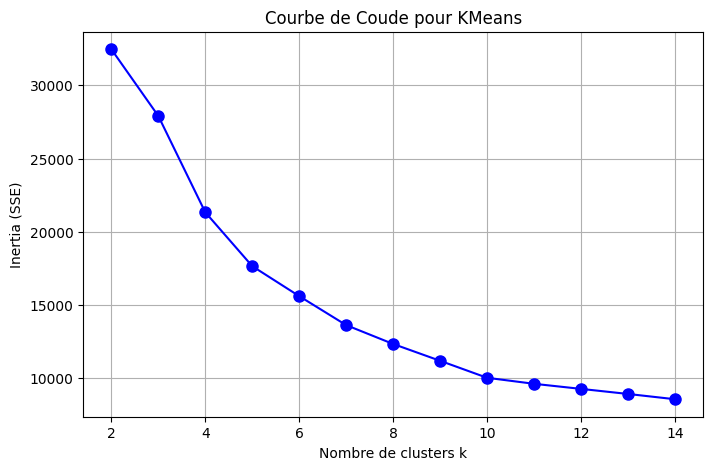

In [7]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertia (SSE)")
plt.title("Courbe de Coude pour KMeans")
plt.grid(True)
plt.show()

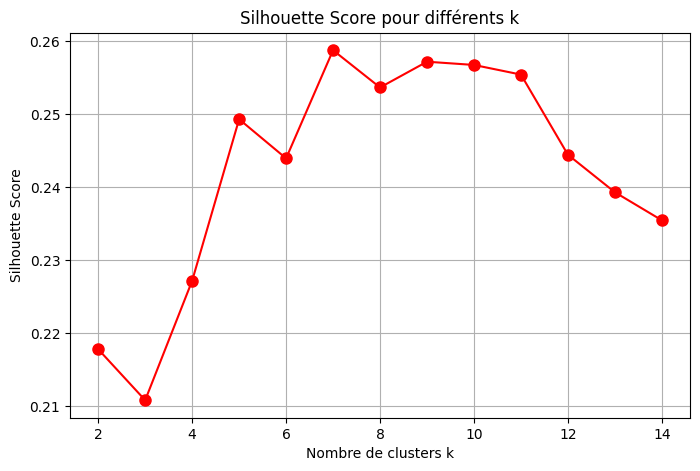

In [8]:
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, 'ro-', markersize=8)
plt.xlabel("Nombre de clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score pour différents k")
plt.grid(True)
plt.show()

**VISUALISATION DES CLUSTERS**

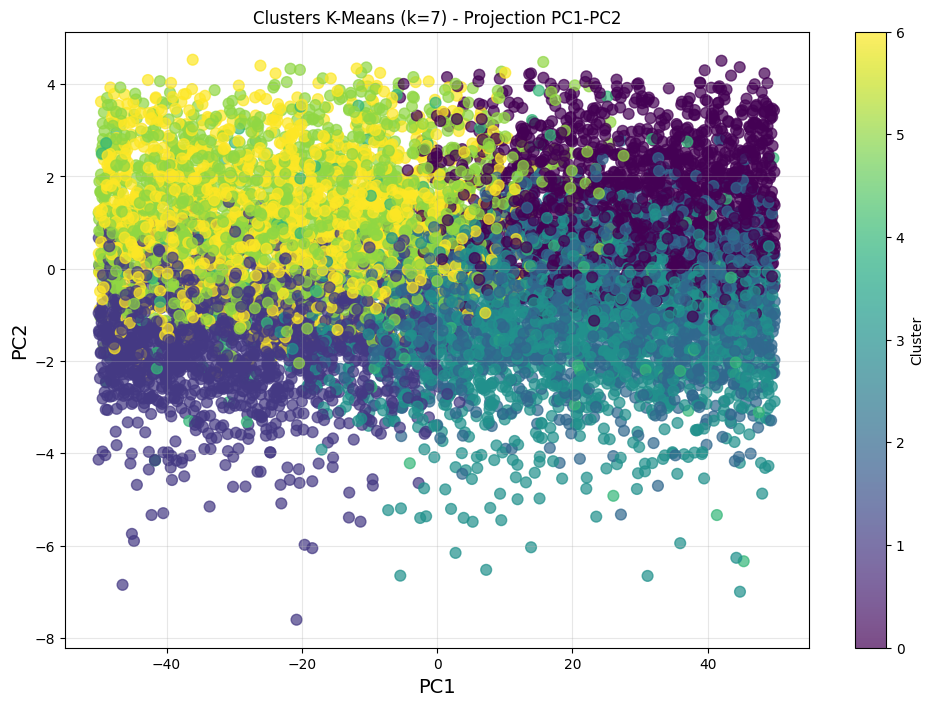

In [9]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=df_engineered['KMeans_Cluster'].values, 
                     cmap='viridis', alpha=0.7, s=60)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.title(f'Clusters K-Means (k={optimal_k}) - Projection PC1-PC2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
for country in df_engineered['Location'].unique():
    print(f"=== {country} ===")
    for cluster in df_engineered['KMeans_Cluster'].unique():
        subset = df_engineered[(df_engineered['Location'] == country) & (df_engineered['KMeans_Cluster'] == cluster)]
        if len(subset) == 0:
            continue
        # Top 5 métiers du cluster
        top_jobs = [str(job) for job in subset['Job_Title'].value_counts().head(5).index.tolist()]
        # Moyennes des indicateurs
        mean_growth = subset['Job_Growth_Rate_%'].mean().round(2)
        mean_salary = subset['Median_Salary_USD'].mean().round(2)
        mean_risk = subset['Automation_Risk_%'].mean().round(2)
        
        print(f"Cluster {cluster}:")
        print(f"  Croissance moyenne : {mean_growth}%")
        print(f"  Salaire moyen : {mean_salary} USD")
        print(f"  Risque d'automatisation : {mean_risk}%")
        print(f"  Métiers principaux : {', '.join(top_jobs)}")


=== canada ===
Cluster 6:
  Croissance moyenne : 82.93%
  Salaire moyen : 120101.84 USD
  Risque d'automatisation : 26.83%
  Métiers principaux : farm manager, advertising account planner, animator, restaurant manager, maintenance engineer
Cluster 3:
  Croissance moyenne : 74.02%
  Salaire moyen : 121502.15 USD
  Risque d'automatisation : 70.01%
  Métiers principaux : education officer, museum, librarian, public, press sub, chartered certified accountant, medical sales representative
Cluster 1:
  Croissance moyenne : 86.97%
  Salaire moyen : 86448.81 USD
  Risque d'automatisation : 22.0%
  Métiers principaux : estate agent, private music teacher, equality and diversity officer, museum/gallery exhibitions officer, occupational therapist
Cluster 0:
  Croissance moyenne : 64.62%
  Salaire moyen : 100489.0 USD
  Risque d'automatisation : 77.56%
  Métiers principaux : facilities manager, surgeon, public affairs consultant, visual merchandiser, retail manager
Cluster 2:
  Croissance moyenne 

In [11]:
# Cluster characteristics
print(f"\n CARACTÉRISTIQUES DES {optimal_k} CLUSTERS:")
cluster_profiles = []
for cluster in sorted(df_engineered['KMeans_Cluster'].unique()):
    cluster_data = df_engineered[df_engineered['KMeans_Cluster'] == cluster]
    
    growth = cluster_data['Job_Growth_Rate_%'].mean().round(2)
    salary = cluster_data['Median_Salary_USD'].mean().round(2)
    risk = cluster_data['Automation_Risk_%'].mean().round(2)
    count = len(cluster_data)
    top_jobs = cluster_data['Job_Title'].value_counts().head(3).index.tolist()
    
    if growth > 10:
        cluster_type = " FORTE CROISSANCE"
    elif growth < -5:
        cluster_type = " FORT DÉCLIN" 
    elif growth > 0:
        cluster_type = "↗ CROISSANCE MODÉRÉE"
    else:
        cluster_type = " STABLE"
    
    cluster_profiles.append({
        'cluster': cluster, 'growth': growth, 'salary': salary, 
        'risk': risk, 'count': count, 'top_jobs': top_jobs, 'type': cluster_type
    })
    
    print(f"\n{cluster_type} - Cluster {cluster}:")
    print(f"   Croissance: {growth}%")
    print(f"   Salaire moyen: {salary} USD")
    print(f"   Risque automation: {risk}%")
    print(f"   {count} métiers")
    print(f"    Métiers: {', '.join(top_jobs)}")



 CARACTÉRISTIQUES DES 7 CLUSTERS:

 FORTE CROISSANCE - Cluster 0:
   Croissance: 75.27%
   Salaire moyen: 96651.21 USD
   Risque automation: 78.74%
   1681 métiers
    Métiers: conservator, museum/gallery, surveyor, insurance, osteopath

 FORTE CROISSANCE - Cluster 1:
   Croissance: 81.84%
   Salaire moyen: 88061.76 USD
   Risque automation: 21.46%
   1707 métiers
    Métiers: occupational therapist, office manager, personal assistant

 FORTE CROISSANCE - Cluster 2:
   Croissance: 80.19%
   Salaire moyen: 56501.19 USD
   Risque automation: 73.29%
   1626 métiers
    Métiers: speech and language therapist, physiological scientist, designer, textile

 FORTE CROISSANCE - Cluster 3:
   Croissance: 78.68%
   Salaire moyen: 122441.86 USD
   Risque automation: 69.8%
   1609 métiers
    Métiers: audiological scientist, psychotherapist, english as a second language teacher

 FORTE CROISSANCE - Cluster 4:
   Croissance: 3399.38%
   Salaire moyen: 88916.73 USD
   Risque automation: 49.39%
   213

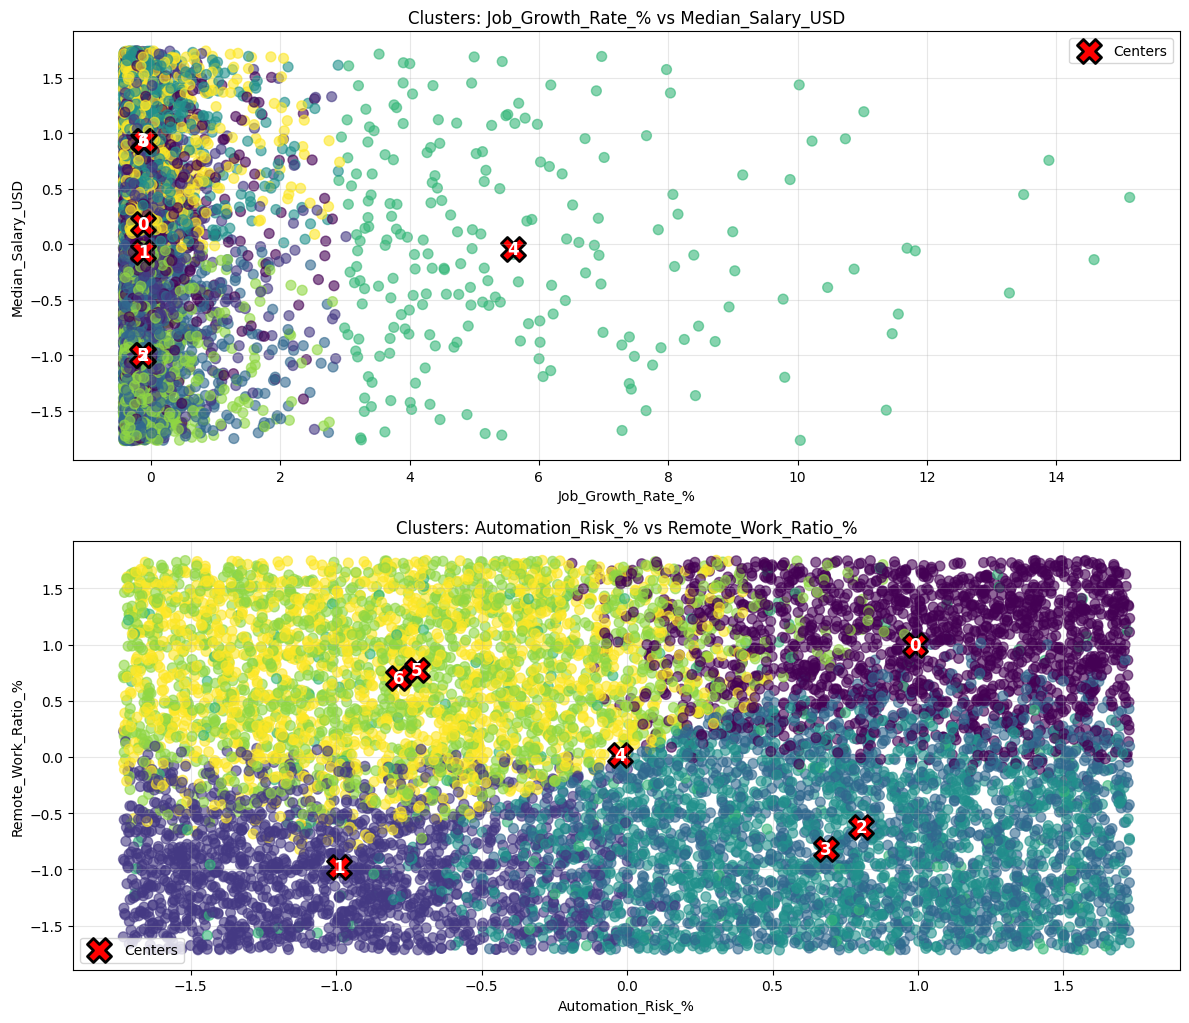

In [12]:
X = X_country_scaled
labels = df_engineered['KMeans_Cluster'].values
centers = kmeans_optimized.cluster_centers_
features = country_features
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
# Plot 1: Feature 0 vs Feature 1
axes[0].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, s=50)
axes[0].scatter(centers[:, 0], centers[:, 1], c='red', s=300, marker='X', 
               edgecolors='black', linewidth=2, label='Centers')
for i, center in enumerate(centers):
    axes[0].text(center[0], center[1], str(i), fontsize=12, fontweight='bold', 
                color='white', ha='center', va='center')
axes[0].set_xlabel(features[0])
axes[0].set_ylabel(features[1])
axes[0].set_title(f'Clusters: {features[0]} vs {features[1]}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Plot 2: Feature 2 vs Feature 3  
axes[1].scatter(X[:, 2], X[:, 3], c=labels, cmap='viridis', alpha=0.6, s=50)
axes[1].scatter(centers[:, 2], centers[:, 3], c='red', s=300, marker='X',
               edgecolors='black', linewidth=2, label='Centers')
for i, center in enumerate(centers):
    axes[1].text(center[2], center[3], str(i), fontsize=12, fontweight='bold',
                color='white', ha='center', va='center')
axes[1].set_xlabel(features[2])
axes[1].set_ylabel(features[3])
axes[1].set_title(f'Clusters: {features[2]} vs {features[3]}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Plot 3: Feature 4 vs Feature 5
if X.shape[1] >= 6:  # Check if we have at least 6 features
    axes[2].scatter(X[:, 4], X[:, 5], c=labels, cmap='viridis', alpha=0.6, s=50)
    axes[2].scatter(centers[:, 4], centers[:, 5], c='red', s=300, marker='X',
                   edgecolors='black', linewidth=2, label='Centers')
    for i, center in enumerate(centers):
        axes[2].text(center[4], center[5], str(i), fontsize=12, fontweight='bold',
                    color='white', ha='center', va='center')
    axes[2].set_xlabel(features[4])
    axes[2].set_ylabel(features[5])
    axes[2].set_title(f'Clusters: {features[4]} vs {features[5]}')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].set_visible(False) 

plt.tight_layout()
plt.show()

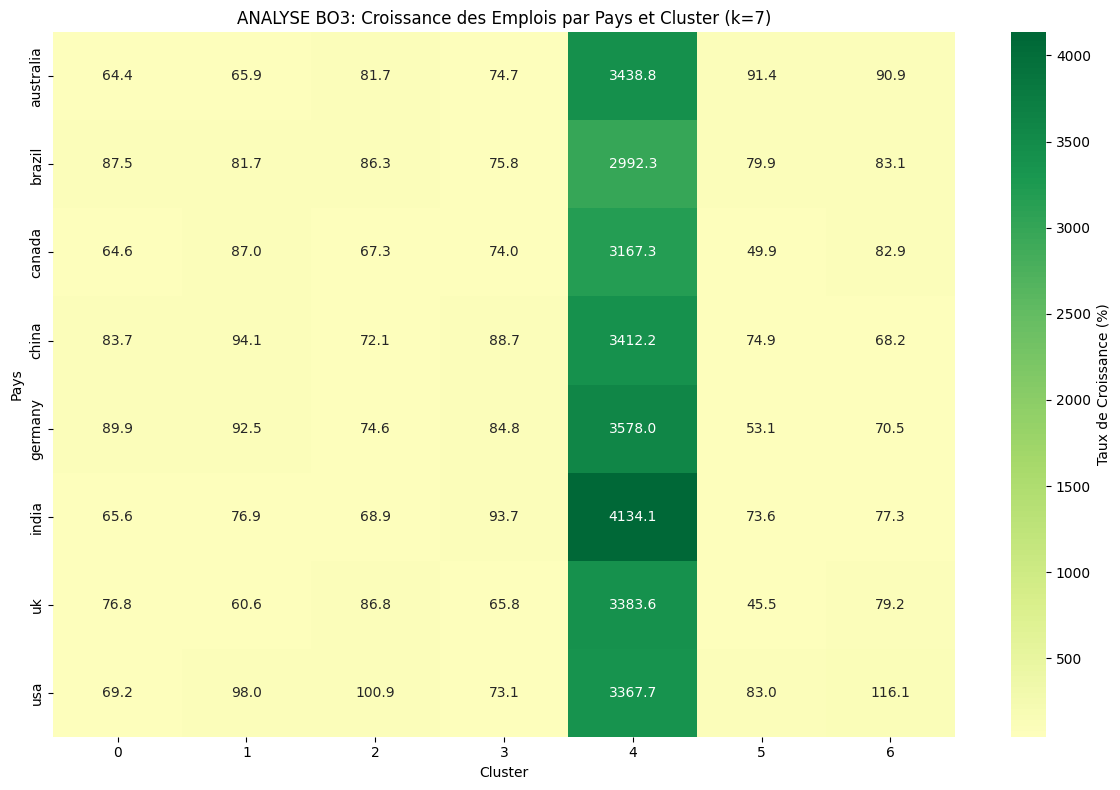

In [13]:
plt.figure(figsize=(12, 8))
growth_pivot = df_engineered.pivot_table(
    values='Job_Growth_Rate_%', 
    index='Location', 
    columns='KMeans_Cluster', 
    aggfunc='mean'
)
sns.heatmap(growth_pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
            cbar_kws={'label': 'Taux de Croissance (%)'})
plt.title(f'ANALYSE BO3: Croissance des Emplois par Pays et Cluster (k={optimal_k})')
plt.xlabel('Cluster')
plt.ylabel('Pays')
plt.tight_layout()
plt.show()

# **K_MEANS   dataset reduit** 

In [14]:
# Sélection des composantes PCA pour le clustering
pca_columns = [col for col in dataset_reduit.columns if col.startswith('PC')]
X = dataset_reduit[pca_columns].copy()
print(f"Variables utilisées pour le clustering: {pca_columns}")
print(f"Shape des données pour clustering: {X.shape}")
# Normalisation des données (comme dans l'exemple World Happiness)
X_values = X.values
X_values = np.nan_to_num(X_values)  # Remplace les NaN par 0
Clus_dataSet = StandardScaler().fit_transform(X_values)

Variables utilisées pour le clustering: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19']
Shape des données pour clustering: (10000, 19)


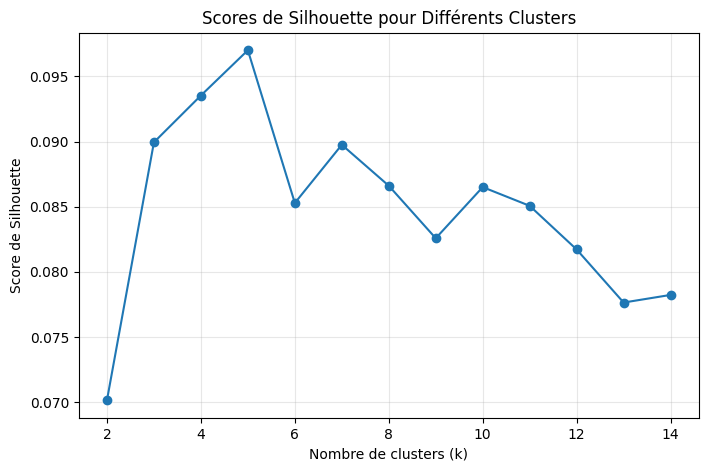

✅ Meilleur k selon silhouette: 5
📊 Meilleur score de silhouette: 0.097


In [15]:
silhouette_scores = []
K_range = range(2, 15) 
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Clus_dataSet)
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(Clus_dataSet, labels))

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Scores de Silhouette pour Différents Clusters')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette')
plt.grid(True, alpha=0.3)
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"✅ Meilleur k selon silhouette: {best_k}")
print(f"📊 Meilleur score de silhouette: {max(silhouette_scores):.3f}")


In [16]:
print(f"\nAPPLICATION DE K-MEANS AVEC k={best_k}...")
clusterNum = best_k
k_means = KMeans(init="k-means++", n_clusters=clusterNum, n_init=12)
k_means.fit(Clus_dataSet)

labels = k_means.labels_
print("Labels des clusters (10 premiers):", labels[:10])

centers = k_means.cluster_centers_
print(f"\nCentres des clusters (shape: {centers.shape})")

inertia = k_means.inertia_
print(f"Inertie: {inertia:.2f}")
silhouette_avg = silhouette_score(Clus_dataSet, labels)
print(f"Score de Silhouette final: {silhouette_avg:.3f}")


APPLICATION DE K-MEANS AVEC k=5...
Labels des clusters (10 premiers): [0 1 1 1 3 3 2 4 2 1]

Centres des clusters (shape: (5, 19))
Inertie: 156220.29
Score de Silhouette final: 0.082



Aperçu des données avec clusters:
         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -19.401484 -0.224040 -2.010792 -1.832659  0.911865 -0.231736 -0.170109   
1  24.000549  0.128053 -1.791350  0.188986  0.958124 -1.873086 -1.774554   
2  -2.687140 -2.186282  2.171883 -0.130280  1.036172 -1.967162 -0.322010   
3  14.220929  1.727547 -0.388235 -1.081332  1.002000 -1.941045 -0.296326   
4  29.717063 -1.727254 -0.966699  3.376978  0.815601  1.920756  0.945769   

        PC8       PC9      PC10  ...      PC15      PC16      PC17      PC18  \
0 -1.318098  0.143974  0.853912  ...  0.797622 -0.146293 -0.573266  0.457854   
1  0.370903  2.287226 -0.509445  ... -0.235384  0.000578  0.052109 -0.052251   
2 -0.322232 -0.121026  0.280840  ... -0.176041  0.292473  0.001916  0.016444   
3  0.659238  0.291277  1.043663  ...  0.239482  0.029664  0.240771 -0.049393   
4 -0.713762 -0.004071  0.551533  ...  0.485565  0.189637  0.072068  0.008179   

           PC19            

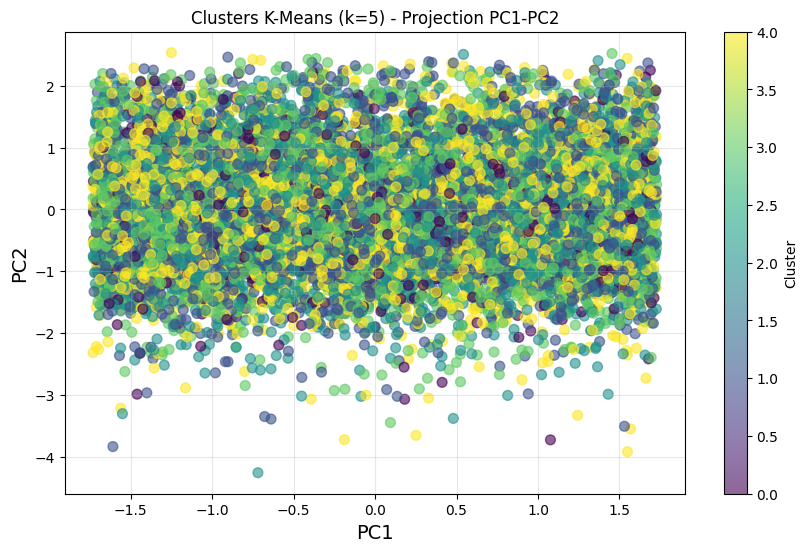

In [17]:
dataset_reduit["Cluster"] = labels
print("\nAperçu des données avec clusters:")
print(dataset_reduit.head())

print("\nDistribution des clusters:")
cluster_distribution = dataset_reduit["Cluster"].value_counts().sort_index()
print(cluster_distribution)
# 1. Visualisation basique PC1 vs PC2 avec les clusters
plt.figure(figsize=(10, 6))
plt.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 1], c=labels.astype(float), alpha=0.6, s=50)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
plt.title(f'Clusters K-Means (k={best_k}) - Projection PC1-PC2')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

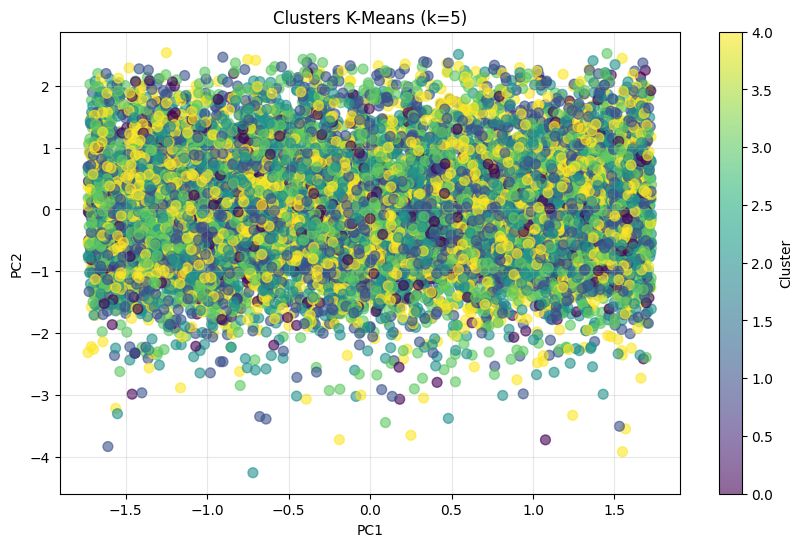

In [18]:
plt.figure(figsize=(10, 6))
if 'Job_Growth_Rate_%' in dataset_reduit.columns:
    sizes = np.abs(dataset_reduit['Job_Growth_Rate_%']) * 10  # Échelle pour la visibilité
    scatter = plt.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 1], c=labels.astype(float), 
                         s=sizes, alpha=0.6, cmap='viridis')
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'Clusters K-Means - Taille basée sur le taux de croissance')
else:
    scatter = plt.scatter(Clus_dataSet[:, 0], Clus_dataSet[:, 1], c=labels.astype(float), 
                         alpha=0.6, s=50, cmap='viridis')
    plt.colorbar(scatter, label='Cluster')
    plt.title(f'Clusters K-Means (k={best_k})')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

**ANALYSE DES CARACTÉRISTIQUES PAR CLUSTER**


In [19]:
print("\nANALYSE DES CARACTÉRISTIQUES PAR CLUSTER...")
# Vérification des colonnes disponibles pour l'analyse
available_columns = dataset_reduit.columns.tolist()
print(f"Colonnes disponibles: {[col for col in available_columns if not col.startswith('PC')]}")
cluster_analysis_cols = ['Cluster']
if 'Job_Growth_Rate_%' in dataset_reduit.columns:
    cluster_analysis_cols.append('Job_Growth_Rate_%')
if 'AI_Impact_Level' in dataset_reduit.columns:
    cluster_analysis_cols.append('AI_Impact_Level')
if 'Growth_Category' in dataset_reduit.columns:
    cluster_analysis_cols.append('Growth_Category')

if len(cluster_analysis_cols) > 1:
    cluster_stats = dataset_reduit[cluster_analysis_cols].groupby('Cluster').agg({
        col: ['mean', 'std'] if dataset_reduit[col].dtype in ['float64', 'int64'] 
        else lambda x: x.mode()[0] if len(x.mode()) > 0 else 'unknown'
        for col in cluster_analysis_cols if col != 'Cluster'
    }).round(2)
    
    print("📊 STATISTIQUES PAR CLUSTER:")
    print(cluster_stats)
else:
    # Si seulement les composantes PCA sont disponibles
    pca_stats = dataset_reduit.groupby('Cluster')[pca_columns].mean().round(2)
    print("📊 STATISTIQUES PCA PAR CLUSTER:")
    print(pca_stats)


ANALYSE DES CARACTÉRISTIQUES PAR CLUSTER...
Colonnes disponibles: ['Job_Title', 'AI_Impact_Level', 'Industry', 'Location', 'Cluster']
📊 STATISTIQUES PAR CLUSTER:
        AI_Impact_Level
Cluster                
0                   low
1                  high
2                  high
3                   low
4              moderate



HEATMAP DES CARACTÉRISTIQUES MOYENNES PAR CLUSTER...


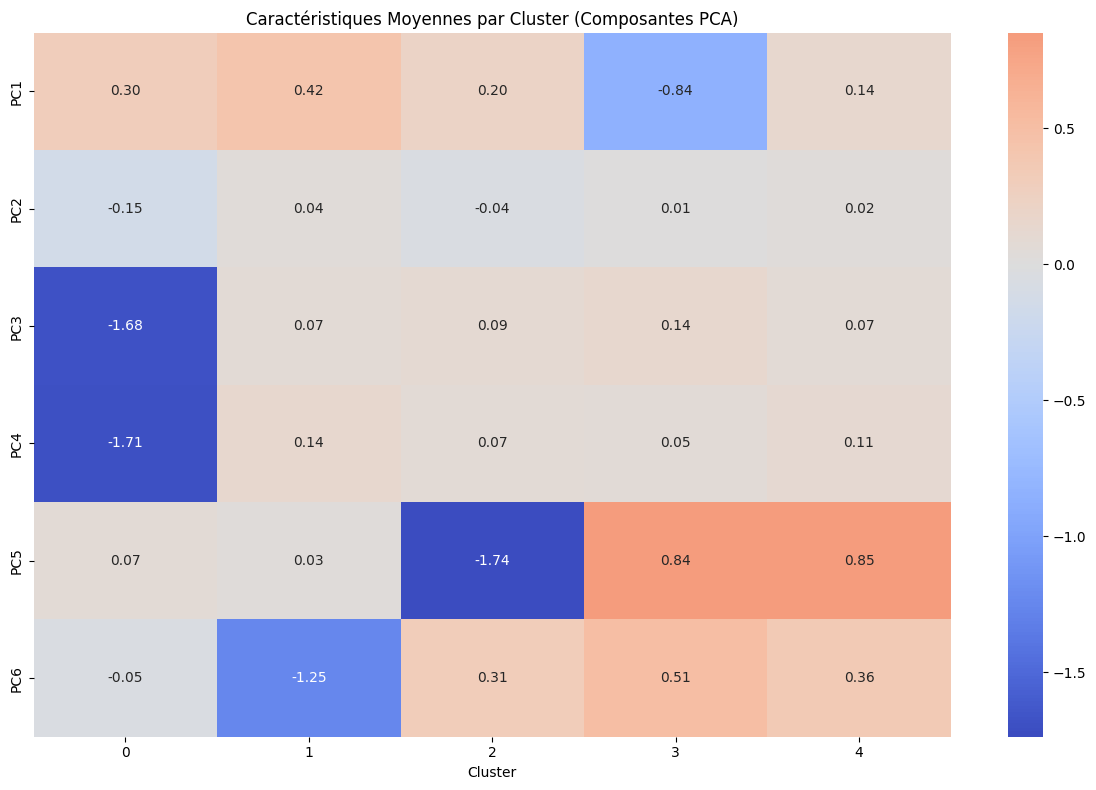

In [20]:
print("\nHEATMAP DES CARACTÉRISTIQUES MOYENNES PAR CLUSTER...")
heatmap_data = dataset_reduit.groupby('Cluster')[pca_columns[:6]].mean()  # Premières 6 composantes

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data.T, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Caractéristiques Moyennes par Cluster (Composantes PCA)')
plt.tight_layout()
plt.show()

X_pca shape: (10000, 23)
Centers shape: (5, 19)
PCA columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19']


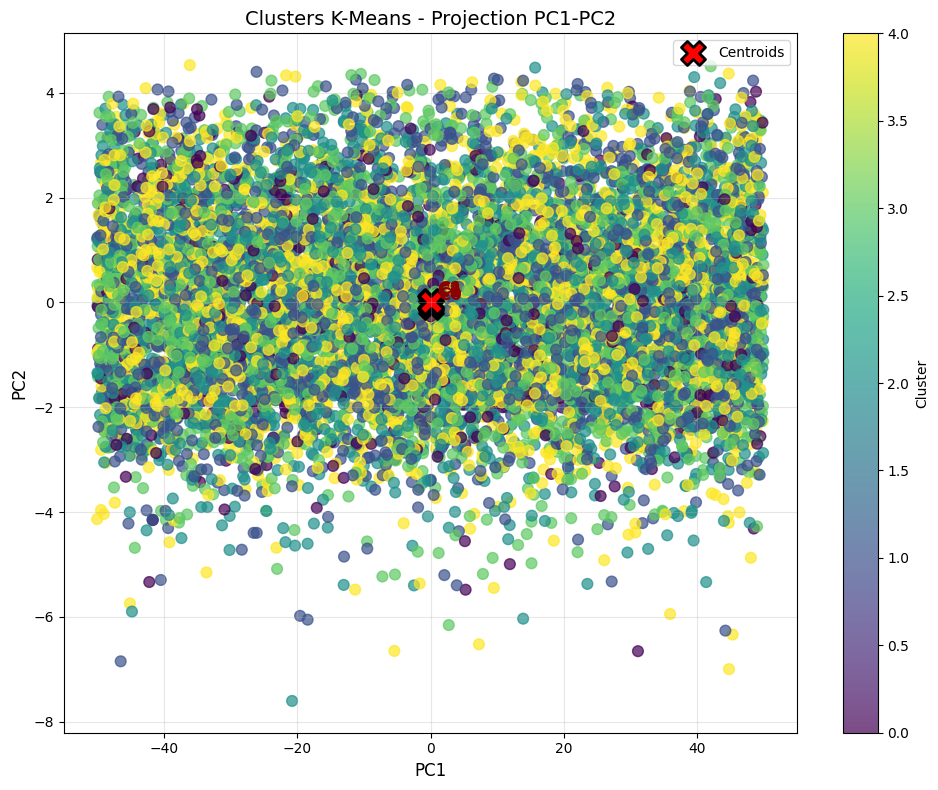

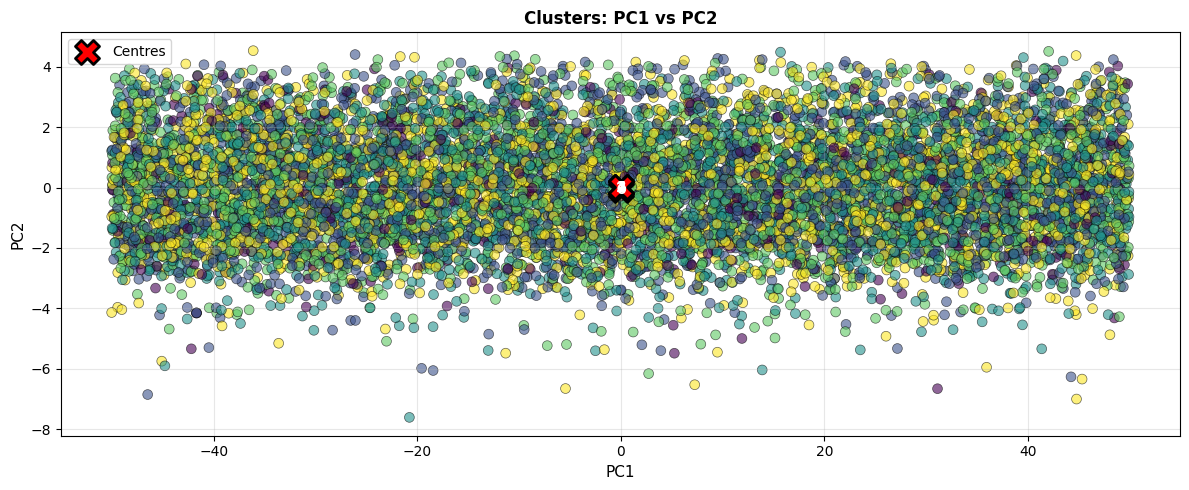

In [21]:
def plot_cluster_multidim(X_scaled, labels, centers, feature_names, optimal_k):
    n_features = X_scaled.shape[1]
    n_pairs = min(3, n_features // 2)
    # Si moins de 2 features, on ne peut pas faire de plot 2D
    if n_pairs == 0:
        print(" Pas assez de features pour la visualisation 2D")
        return
    fig, axes = plt.subplots(n_pairs, 1, figsize=(12, 5 * n_pairs))
    # Gérer le cas d'un seul subplot
    if n_pairs == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        idx_x = 2 * i
        idx_y = 2 * i + 1
     
        # Vérifier que les indices sont dans les limites
        if idx_y < n_features and idx_y < centers.shape[1]:
            # Points des clusters
            scatter = ax.scatter(X_scaled[:, idx_x], X_scaled[:, idx_y],
                               c=labels, cmap='viridis', alpha=0.6, s=50,
                               edgecolors='k', linewidth=0.5)
            
            # Centres des clusters (seulement si disponibles)
            if centers.shape[1] > max(idx_x, idx_y):
                ax.scatter(centers[:, idx_x], centers[:, idx_y], 
                          c='red', s=300, marker='X', edgecolors='black', 
                          linewidth=2, label='Centres', zorder=10)
                
                # Numérotation des centres
                for cluster_id, center in enumerate(centers):
                    ax.text(center[idx_x], center[idx_y], str(cluster_id),
                           fontsize=10, fontweight='bold', color='white',
                           ha='center', va='center', zorder=11)
            
            ax.set_xlabel(feature_names[idx_x], fontsize=11)
            ax.set_ylabel(feature_names[idx_y], fontsize=11)
            ax.set_title(f'Clusters: {feature_names[idx_x]} vs {feature_names[idx_y]}',
                        fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        else:
            # Cacher les subplots inutilisés
            ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()

def plot_pca_clusters_simple(X_pca, labels, centers, feature_names):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                         c=labels, cmap='viridis', alpha=0.7, s=60)
    
    if centers.shape[1] >= 2:
        plt.scatter(centers[:, 0], centers[:, 1],
                   c='red', s=300, marker='X', edgecolors='black',
                   linewidth=2, label='Centroids')
        
        for i, center in enumerate(centers):
            plt.annotate(f'C{i}', (center[0], center[1]),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=12, fontweight='bold', color='darkred')
    
    plt.xlabel(f'{feature_names[0]}', fontsize=12)
    plt.ylabel(f'{feature_names[1]}', fontsize=12)
    plt.title('Clusters K-Means - Projection PC1-PC2', fontsize=14)
    plt.colorbar(scatter, label='Cluster')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
# VÉRIFICATION DES DIMENSIONS AVANT L'APPEL
print(f"X_pca shape: {X_pca.shape}")
print(f"Centers shape: {k_means.cluster_centers_.shape}")
print(f"PCA columns: {pca_columns}")

# APPEL CORRIGÉ - Utilisation de la version simplifiée
plot_pca_clusters_simple(X_pca, 
                        dataset_reduit['Cluster'].values,
                        k_means.cluster_centers_,
                        pca_columns)

# Alternative : utiliser seulement les 2 premières composantes pour la version multidim
if X_pca.shape[1] >= 2 and k_means.cluster_centers_.shape[1] >= 2:
    plot_cluster_multidim(X_pca[:, :2],
                         dataset_reduit['Cluster'].values,
                         k_means.cluster_centers_[:, :2],  
                         pca_columns[:2],  
                         best_k)

# **DBSCAN**

In [22]:
# Préparation et k-distance plot

print(" Utilisation des mêmes données que K-means")
print(f"Features: {country_features}")
print(f"Shape: {X_country_scaled.shape}")
# ---- minPts basé sur la règle D+1
D = len(country_features)
minPts = D + 1   # règle standard DBSCAN
print("\n CALCUL DE minPts:")
print(f" • Nombre de features = {D}")
print(f" • minPts = D + 1 = {minPts}")

 Utilisation des mêmes données que K-means
Features: ['Job_Growth_Rate_%', 'Median_Salary_USD', 'Automation_Risk_%', 'Remote_Work_Ratio_%']
Shape: (10000, 4)

 CALCUL DE minPts:
 • Nombre de features = 4
 • minPts = D + 1 = 5


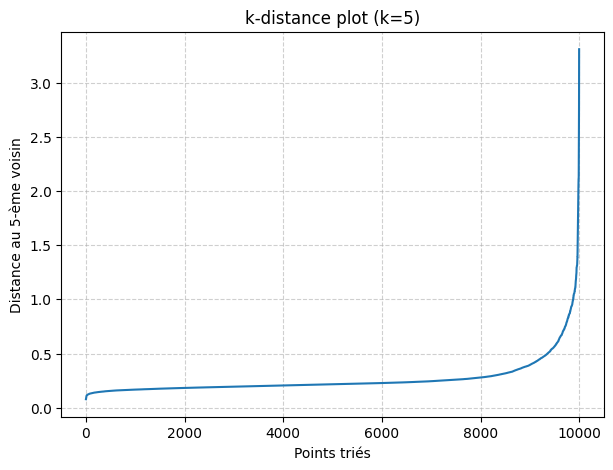

In [23]:
# ---- k-distance pour un premier aperçu
nbrs = NearestNeighbors(n_neighbors=minPts).fit(X_country_scaled)
k_dists, _ = nbrs.kneighbors(X_country_scaled)
k_dists = np.sort(k_dists[:, -1])

plt.figure(figsize=(7,5))
plt.plot(k_dists)
plt.title(f"k-distance plot (k={minPts})")
plt.xlabel("Points triés")
plt.ylabel(f"Distance au {minPts}-ème voisin")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [24]:
# SECTION 2 — Candidats epsilon
epsilon_p90 = np.percentile(k_dists, 90)
epsilon_p95 = np.percentile(k_dists, 95)
epsilon_mean = np.mean(k_dists)

print("\nCANDIDATS EPSILON (basés sur la distribution):")
print(f" • Percentile 90% : {epsilon_p90:.3f}")
print(f" • Percentile 95% : {epsilon_p95:.3f}")
print(f" • Moyenne : {epsilon_mean:.3f}")

# ---- Grille d'epsilon élargie autour des valeurs
eps_candidates = np.concatenate([
    np.linspace(epsilon_p90*0.6, epsilon_p90*1.4, 6),
    np.linspace(epsilon_p95*0.6, epsilon_p95*1.4, 6),
    np.linspace(epsilon_mean*0.6, epsilon_mean*1.4, 6)
])

eps_candidates = np.round(eps_candidates, 3)
eps_candidates = np.unique(eps_candidates)
eps_candidates = eps_candidates[eps_candidates > 0]
eps_candidates = sorted(eps_candidates.tolist())

print("\nListe étendue des eps testés:")
print(eps_candidates)


CANDIDATS EPSILON (basés sur la distribution):
 • Percentile 90% : 0.395
 • Percentile 95% : 0.566
 • Moyenne : 0.265

Liste étendue des eps testés:
[0.159, 0.201, 0.237, 0.243, 0.286, 0.3, 0.328, 0.34, 0.363, 0.37, 0.426, 0.43, 0.489, 0.521, 0.552, 0.612, 0.702, 0.793]


In [25]:
# SECTION 3 — Test de tous les eps
results = []
for eps in eps_candidates:
    db = DBSCAN(eps=eps, min_samples=minPts).fit(X_country_scaled)
    labels = db.labels_
    
    n_noise = list(labels).count(-1)
    noise_ratio = n_noise / len(labels)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Score simple : favoriser moins de bruit et entre 2 et 15 clusters
    if 2 <= n_clusters <= 15:
        quality = (1 - noise_ratio) * n_clusters
    else:
        quality = -1  # non raisonnable
    
    results.append([eps, n_clusters, noise_ratio, quality])

df_grid = pd.DataFrame(results, columns=["eps", "n_clusters", "noise_ratio", "quality"])

print("\nAperçu de la grille:")
display(df_grid.head())



Aperçu de la grille:


,eps,n_clusters,noise_ratio,quality
0,0.159,238,0.8292,-1.000
1,0.201,163,0.3791,-1.000
2,0.237,19,0.2025,-1.000
3,0.243,19,0.1873,-1.000
4,0.286,5,0.1342,4.329


In [26]:
# ---- filtrer les eps raisonnables
reasonable = df_grid[(df_grid.n_clusters.between(2, 15))]
reasonable = reasonable.sort_values(by="quality", ascending=False)

print("\nEPS raisonnables triés:")
display(reasonable.head())

# ---- choix final
if len(reasonable) > 0:
    best_epsilon = reasonable.iloc[0]["eps"]
else:
    best_epsilon = epsilon_p90  # fallback
print(f"\n🎯 EPSILON FINAL CHOISI = {best_epsilon}")


EPS raisonnables triés:


,eps,n_clusters,noise_ratio,quality
9,0.370,10,0.0858,9.1420
8,0.363,8,0.0907,7.2744
5,0.300,8,0.1228,7.0176
13,0.521,7,0.0452,6.6836
11,0.430,7,0.0648,6.5464



🎯 EPSILON FINAL CHOISI = 0.37


In [27]:
# SECTION 4 — DBSCAN FINAL
dbscan = DBSCAN(eps=best_epsilon, min_samples=minPts)
dbscan_labels = dbscan.fit_predict(X_country_scaled)

df_engineered["DBSCAN_Cluster"] = dbscan_labels

unique_labels = np.unique(dbscan_labels)
n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print("\n📊 RÉSULTATS DBSCAN:")
print(f" • Clusters détectés : {n_clusters}")
print(f" • Bruit : {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f" • Labels : {unique_labels}")


📊 RÉSULTATS DBSCAN:
 • Clusters détectés : 10
 • Bruit : 858 (8.6%)
 • Labels : [-1  0  1  2  3  4  5  6  7  8  9]


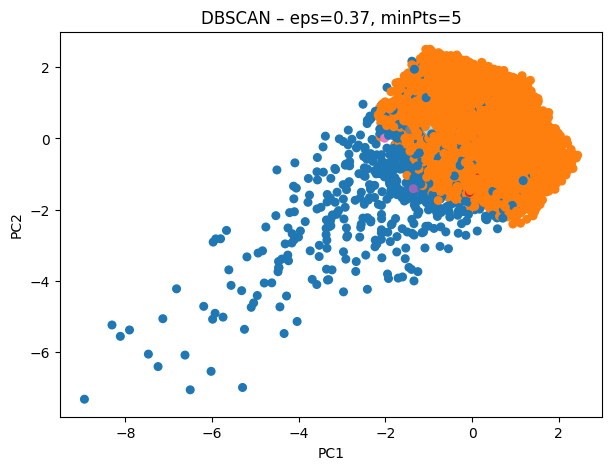

In [28]:
# SECTION 5 — Visualisation
pca_vis = PCA(n_components=2).fit_transform(X_country_scaled)

plt.figure(figsize=(7,5))
plt.scatter(pca_vis[:,0], pca_vis[:,1], c=dbscan_labels, cmap="tab20", s=30)
plt.title(f"DBSCAN – eps={best_epsilon}, minPts={minPts}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

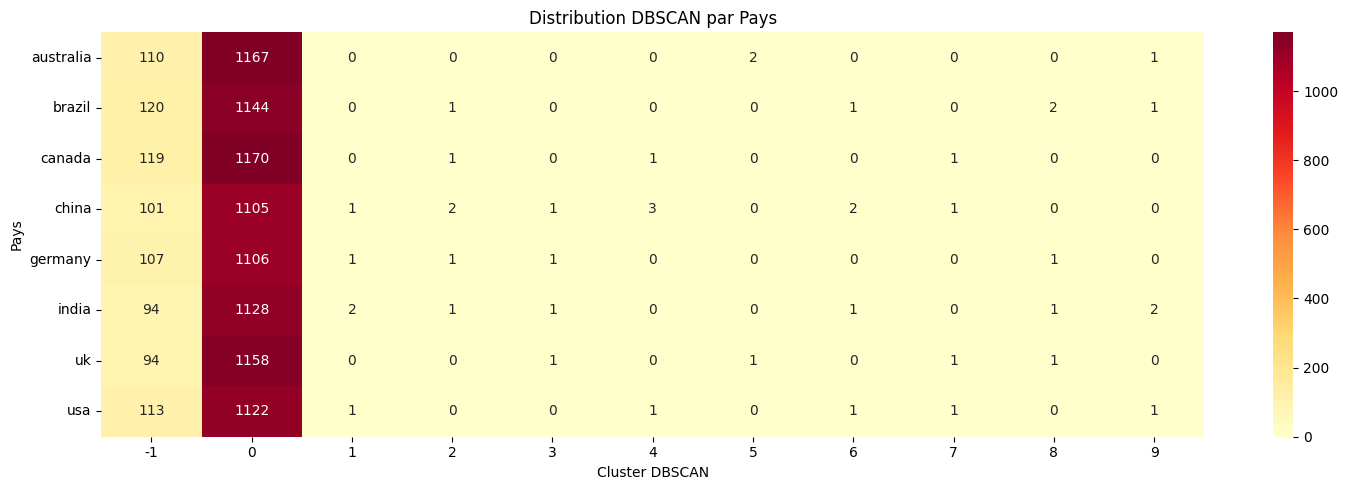

In [29]:
plt.figure(figsize=(15, 5))
if n_clusters > 0:
    cluster_by_country = df_engineered.groupby(['Location', 'DBSCAN_Cluster']).size().unstack(fill_value=0)
    sns.heatmap(cluster_by_country, annot=True, fmt='d', cmap='YlOrRd')
    plt.title('Distribution DBSCAN par Pays')
    plt.xlabel('Cluster DBSCAN')
    plt.ylabel('Pays')
else:
    plt.text(0.5, 0.5, 'Aucun cluster détecté', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('Aucun Cluster DBSCAN')

plt.tight_layout()
plt.show()

In [30]:

# ANALYSE DÉTAILLÉE DES CLUSTERS
print(f"\nANALYSE DÉTAILLÉE DES CLUSTERS DBSCAN:")
for cluster_id in sorted(unique_labels):
    cluster_data = df_engineered[df_engineered['DBSCAN_Cluster'] == cluster_id]
    
    if cluster_id == -1:
        print(f"\n CLUSTER -1 (BRUIT - {len(cluster_data)} métiers):")
    else:
        print(f"\n CLUSTER {cluster_id} ({len(cluster_data)} métiers):")
    
    if len(cluster_data) > 0:
        growth = cluster_data['Job_Growth_Rate_%'].mean()
        salary = cluster_data['Median_Salary_USD'].mean()
        risk = cluster_data['Automation_Risk_%'].mean()
        remote = cluster_data['Remote_Work_Ratio_%'].mean()
        
        print(f"   Croissance: {growth:.1f}%")
        print(f"   Salaire: {salary:.0f} USD")
        print(f"     Risque automation: {risk:.1f}%")
        print(f"    Télétravail: {remote:.1f}%")
        
        top_jobs = cluster_data['Job_Title'].value_counts().head(3).index.tolist()
        print(f"    Top métiers: {', '.join(top_jobs)}")
        
        if cluster_id != -1:
            # Top pays pour les clusters normaux
            top_countries = cluster_data['Location'].value_counts().head(2).index.tolist()
            print(f"    Top pays: {', '.join(top_countries)}")


ANALYSE DÉTAILLÉE DES CLUSTERS DBSCAN:

 CLUSTER -1 (BRUIT - 858 métiers):
   Croissance: 1480.9%
   Salaire: 89446 USD
     Risque automation: 50.3%
    Télétravail: 49.1%
    Top métiers: analytical chemist, psychologist, occupational, civil engineer, contracting

 CLUSTER 0 (9100 métiers):
   Croissance: 21.3%
   Salaire: 90597 USD
     Risque automation: 50.1%
    Télétravail: 49.5%
    Top métiers: database administrator, psychotherapist, speech and language therapist
    Top pays: canada, australia

 CLUSTER 1 (5 métiers):
   Croissance: 751.6%
   Salaire: 111566 USD
     Risque automation: 23.9%
    Télétravail: 51.1%
    Top métiers: air traffic controller, scientist, water quality, minerals surveyor
    Top pays: india, china

 CLUSTER 2 (6 métiers):
   Croissance: 627.4%
   Salaire: 108554 USD
     Risque automation: 38.4%
    Télétravail: 25.7%
    Top métiers: therapist, speech and language, recruitment consultant, paediatric nurse
    Top pays: china, canada

 CLUSTER 3 (

# **CAH** 

In [31]:
# Vérification des colonnes requises
required = ['Location', 'Job_Title', 'Job_Growth_Rate_%']
missing = [c for c in required if c not in df_engineered.columns]
if missing:
    print(f"❌ Colonnes manquantes: {missing}")
else:
    # Création de la matrice pivot
    pivot_df = df_engineered.pivot_table(
        values='Job_Growth_Rate_%',
        index='Location',
        columns='Job_Title',
        aggfunc='mean'
    ).fillna(0)

    print(f"Pivot matrix shape (locations x jobs): {pivot_df.shape}")
    
    # Standardisation
    scaler = StandardScaler()
    pivot_scaled = scaler.fit_transform(pivot_df.values)   
    print(f"Scaled data mean: {pivot_scaled.mean():.3f}, std: {pivot_scaled.std():.3f}")
    print(f"Pays analysés : {pivot_df.index.tolist()}")


Pivot matrix shape (locations x jobs): (8, 639)
Scaled data mean: 0.000, std: 1.000
Pays analysés : ['australia', 'brazil', 'canada', 'china', 'germany', 'india', 'uk', 'usa']


C:\Users\meria\AppData\Local\Temp\ipykernel_16932\2468012182.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


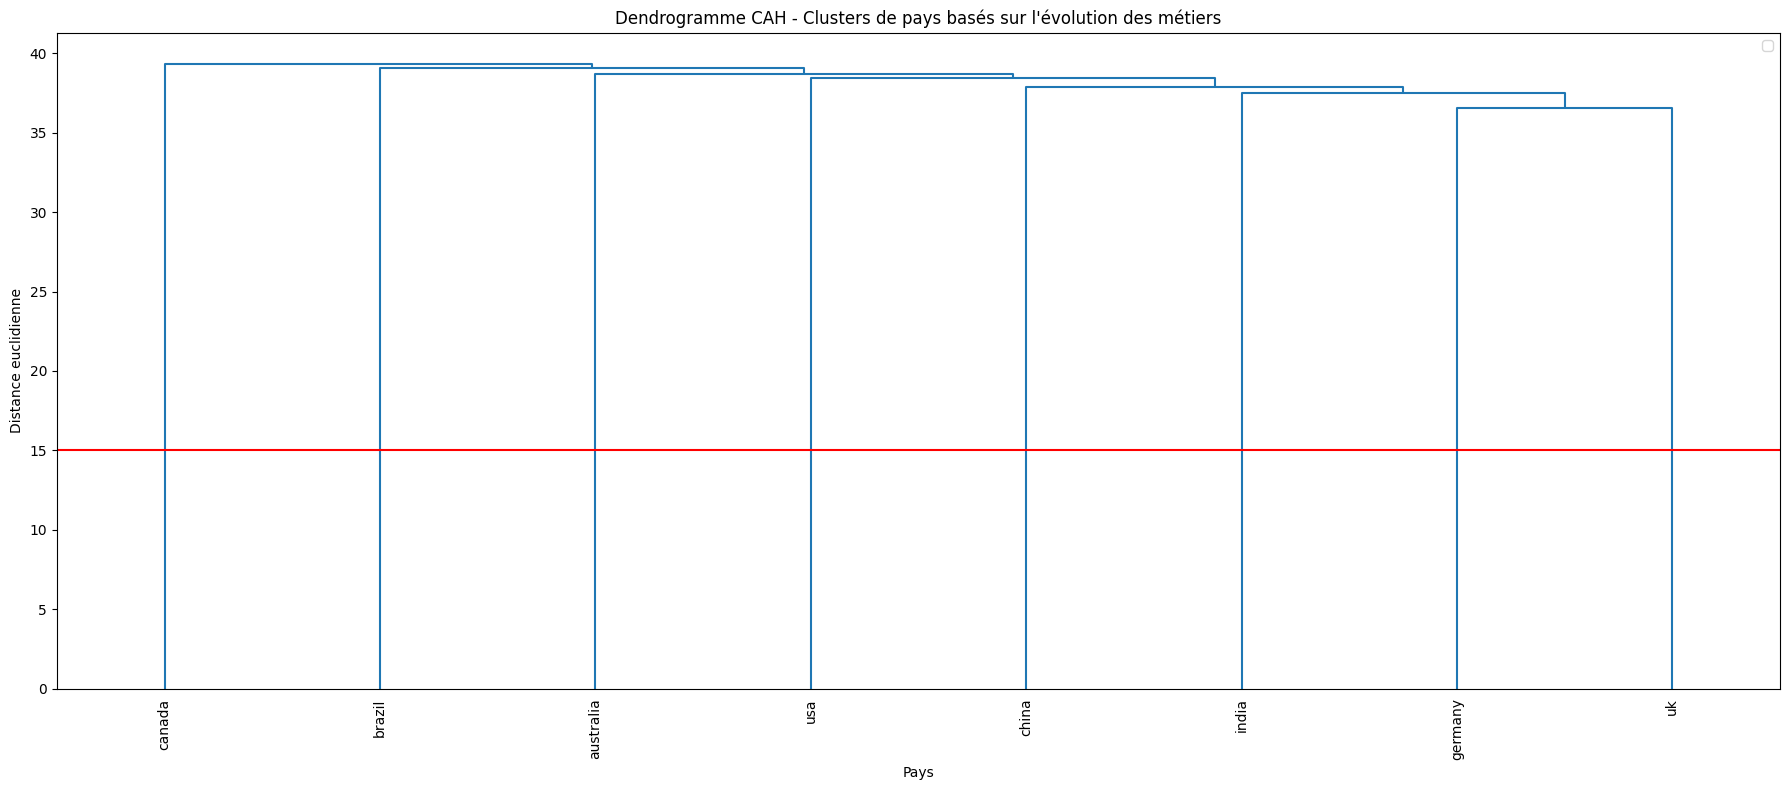

In [32]:
# Méthode 1: CAH avec scipy (pour le dendrogramme)
Z = linkage(pivot_scaled, method='ward', metric='euclidean')

# Visualisation du dendrogramme pour choisir le nombre de clusters
plt.figure(figsize=(18, 8))
dendrogram(Z,
          labels=pivot_df.index.tolist(),
          leaf_rotation=90,
          leaf_font_size=10,
          color_threshold=15)
plt.title('Dendrogramme CAH - Clusters de pays basés sur l\'évolution des métiers')
plt.axhline(y=15, color='r',)
plt.ylabel('Distance euclidienne')
plt.xlabel('Pays')
plt.legend()
plt.tight_layout()
plt.show()

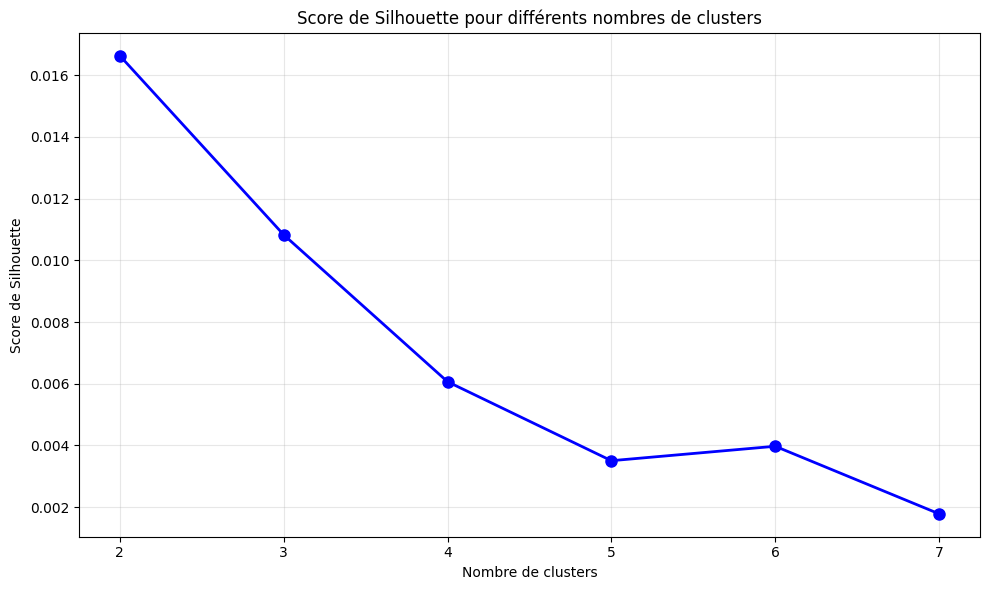

In [33]:
# Calcul du score de silhouette pour différents nombres de clusters
silhouette_scores = []
cluster_range = range(2, min(8, len(pivot_df)))  # Éviter plus de clusters que de pays

for n_clusters in cluster_range:
    # Méthode 2: CAH avec scikit-learn (plus moderne)
    hc = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='euclidean',
        linkage='ward'
    )
    cluster_labels = hc.fit_predict(pivot_scaled)

    if len(set(cluster_labels)) > 1:  # Éviter erreur si un seul cluster
        score = silhouette_score(pivot_scaled, cluster_labels)
        silhouette_scores.append(score)
    else:
        silhouette_scores.append(0)

# Visualisation des scores de silhouette
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.title('Score de Silhouette pour différents nombres de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de Silhouette')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [34]:
# Choix du nombre optimal de clusters
optimal_clusters = cluster_range[np.argmax(silhouette_scores)]
print(f"Nombre optimal de clusters (selon silhouette) : {optimal_clusters}")

# Utilisation du nombre optimal ou d'une valeur fixe selon le contexte
num_clusters = optimal_clusters  


Nombre optimal de clusters (selon silhouette) : 2


In [35]:
hc_final = AgglomerativeClustering(
    n_clusters=num_clusters,
    metric='euclidean',
    linkage='ward'
)
clusters = hc_final.fit_predict(pivot_scaled)
pivot_df['Cluster'] = clusters

for cluster_num in range(num_clusters):
    countries_in_cluster = pivot_df[pivot_df['Cluster'] == cluster_num].index.tolist()
    print(f"Cluster {cluster_num}: {countries_in_cluster}")

def analyze_cluster_variations(cluster_matrix, cluster_num):
    cluster_means = cluster_matrix.mean(axis=0).sort_values(ascending=False)
    top_increase = cluster_means.head(10)
    top_decrease = cluster_means.tail(10)
    print(f"\nCluster {cluster_num} summary ")
    print(f"Countries: {', '.join(cluster_matrix.index.tolist())}")
    print(f"Mean growth (all jobs): {cluster_means.mean():+.2f}%")
    print("\nTop increases (jobs):")
    print(top_increase.head(5))
    print("\nTop decreases (jobs):")
    print(top_decrease.head(5))
    return top_increase, top_decrease
print("\nDETAILED CLUSTER VARIATIONS")
for c in range(num_clusters):
    cluster_data = pivot_df[pivot_df['Cluster'] == c].drop(columns='Cluster')
    analyze_cluster_variations(cluster_data, c)

Cluster 0: ['australia', 'brazil', 'china', 'germany', 'india', 'uk', 'usa']
Cluster 1: ['canada']

DETAILED CLUSTER VARIATIONS

Cluster 0 summary 
Countries: australia, brazil, china, germany, india, uk, usa
Mean growth (all jobs): +125.42%

Top increases (jobs):
Job_Title
academic librarian                    1214.092298
corporate investment banker           1184.816774
tourist information centre manager     981.561711
aid worker                             919.501330
radiographer, therapeutic              884.943194
dtype: float64

Top decreases (jobs):
Job_Title
adult guidance worker           -24.206326
commissioning editor            -25.984433
market researcher               -26.813907
stage manager                   -27.673421
telecommunications researcher   -28.444198
dtype: float64

Cluster 1 summary 
Countries: canada
Mean growth (all jobs): +120.65%

Top increases (jobs):
Job_Title
scientist, biomedical       5377.528090
technical author            3038.323353
sports coach 

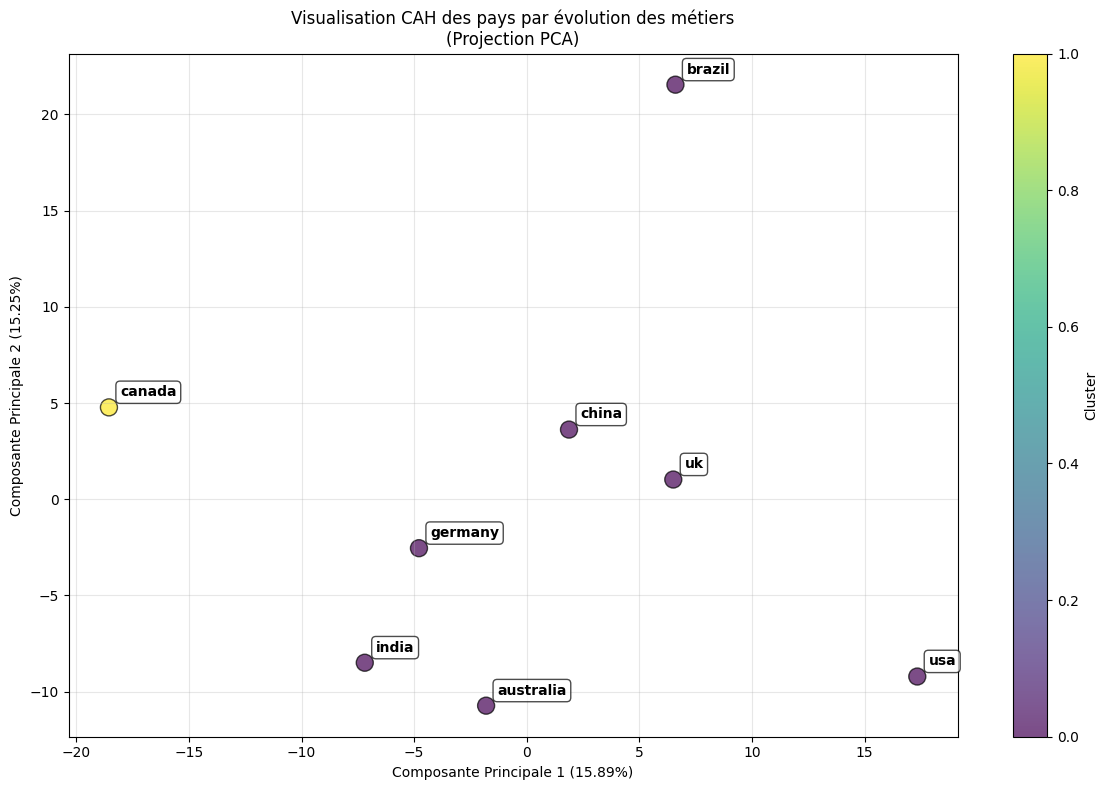

In [36]:
# Réduction de dimension avec PCA
pca = PCA(n_components=2)
pivot_pca = pca.fit_transform(pivot_scaled)

# Créer un DataFrame pour la visualisation
pca_df = pd.DataFrame({
    'PC1': pivot_pca[:, 0],
    'PC2': pivot_pca[:, 1],
    'Cluster': clusters,
    'Country': pivot_df.index
})

plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'],
                     cmap='viridis', s=150, alpha=0.7, edgecolors='black')
# Ajouter les labels des pays
for i, country in enumerate(pca_df['Country']):
    plt.annotate(country, (pca_df['PC1'][i], pca_df['PC2'][i]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

plt.colorbar(scatter, label='Cluster')
plt.title('Visualisation CAH des pays par évolution des métiers\n(Projection PCA)')
plt.xlabel(f'Composante Principale 1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Composante Principale 2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Calcul des statistiques globales
cluster_stats = []
for cluster_num in range(num_clusters):
    cluster_data = pivot_df[pivot_df['Cluster'] == cluster_num].drop('Cluster', axis=1)
    countries = cluster_data.index.tolist()
    mean_growth = cluster_data.values.mean()
    std_growth = cluster_data.values.std()

    cluster_stats.append({
        'Cluster': cluster_num,
        'Pays': countries,
        'Croissance Moyenne': mean_growth,
        'Variabilité': std_growth
    })

# Tri par croissance moyenne
cluster_stats_sorted = sorted(cluster_stats, key=lambda x: x['Croissance Moyenne'], reverse=True)

for i, stats in enumerate(cluster_stats_sorted, 1):
    print(f"\n{i}. Cluster {stats['Cluster']}:")
    print(f"   Pays: {', '.join(stats['Pays'])}")
    print(f"   Croissance moyenne: {stats['Croissance Moyenne']:+.1f}%")
    print(f"   Variabilité: {stats['Variabilité']:.1f}%")

# Identification des tendances globales
most_growth_cluster = cluster_stats_sorted[0]
least_growth_cluster = cluster_stats_sorted[-1]

print(f"\n CONCLUSIONS STRATÉGIQUES:")
print(f"• Le cluster le plus dynamique est le Cluster {most_growth_cluster['Cluster']} "
      f"({most_growth_cluster['Croissance Moyenne']:+.1f}%)")
print(f"• Le cluster le plus en difficulté est le Cluster {least_growth_cluster['Cluster']} "
      f"({least_growth_cluster['Croissance Moyenne']:+.1f}%)")
print(f"• Score de silhouette moyen: {silhouette_score(pivot_scaled, clusters):.3f}")

print(f"\nANALYSE TERMINÉE AVEC SUCCÈS!")
print(f"• {len(pivot_df)} pays analysés")
print(f"• {pivot_df.shape[1]-1} métiers considérés")
print(f"• {num_clusters} clusters identifiés")



1. Cluster 0:
   Pays: australia, brazil, china, germany, india, uk, usa
   Croissance moyenne: +125.4%
   Variabilité: 398.8%

2. Cluster 1:
   Pays: canada
   Croissance moyenne: +120.6%
   Variabilité: 383.7%

 CONCLUSIONS STRATÉGIQUES:
• Le cluster le plus dynamique est le Cluster 0 (+125.4%)
• Le cluster le plus en difficulté est le Cluster 1 (+120.6%)
• Score de silhouette moyen: 0.017

ANALYSE TERMINÉE AVEC SUCCÈS!
• 8 pays analysés
• 639 métiers considérés
• 2 clusters identifiés
